In [18]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [20]:

df_train = pd.read_csv('/content/train.csv')
df_train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [21]:
stores = pd.read_csv('/content/stores.csv')
features = pd.read_csv('/content/features.csv')

In [22]:

df = df_train.merge(stores, how='left', on='Store')
df = df.merge(features, how='left', on=['Store', 'Date'])
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [23]:

df['Date'] = pd.to_datetime(df['Date'])


df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week


df[['Date', 'Year', 'Month', 'Week']].head()

,Date,Year,Month,Week
0,2010-02-05,2010,2,5
1,2010-02-12,2010,2,6
2,2010-02-19,2010,2,7
3,2010-02-26,2010,2,8
4,2010-03-05,2010,3,9


In [24]:

df['Day'] = df['Date'].dt.day
df['Week'] = df['Week'].astype(int)


print("--- missing values ---")
print(df.isnull().sum())


df = df.rename(columns={'IsHoliday_x': 'IsHoliday'})


X = df[['Store', 'Dept', 'IsHoliday', 'Year', 'Month', 'Week', 'Day']]
y = df['Weekly_Sales']

print("\n--- X and y shapes ---")
print("Features shape (X):", X.shape)
print("Target shape (y):", y.shape)

--- missing values ---
Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday_x          0
Type                 0
Size                 0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
IsHoliday_y          0
Year                 0
Month                0
Week                 0
Day                  0
dtype: int64

--- X and y shapes ---
Features shape (X): (421570, 7)
Target shape (y): (421570,)


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=20, random_state=42, n_jobs=-1)
print("Training the model... Please wait.")
model.fit(X_train, y_train)
print("Model training completed successfully!")

Training the model... Please wait.
Model training completed successfully!


In [26]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared Score (R2): {r2}")

Mean Absolute Error (MAE): 1392.3558796463224
R-squared Score (R2): 0.9715226316631186


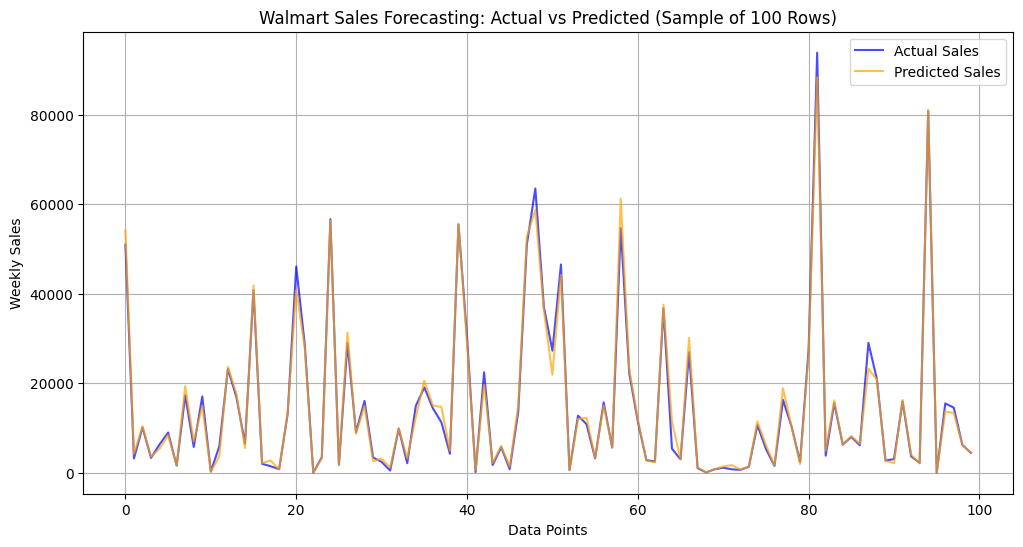

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:100], label='Actual Sales', color='blue', alpha=0.7)
plt.plot(y_pred[:100], label='Predicted Sales', color='orange', alpha=0.7)

plt.title('Walmart Sales Forecasting: Actual vs Predicted (Sample of 100 Rows)')
plt.xlabel('Data Points')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
import pandas as pd

# 1. Create a dataframe with only the features your model was trained on
future_data = pd.DataFrame({
    'Store': [1],
    'Dept': [1],
    'IsHoliday': [0],
    'Year': [2026],
    'Month': [6],
    'Week': [25],
    'Day': [20]
})

# 2. Select the matching features
features = ['Store', 'Dept', 'IsHoliday', 'Year', 'Month', 'Week', 'Day']
X_future = future_data[features]

# 3. Predict the future weekly sales
try:
    future_predictions = model.predict(X_future)
    print("=" * 40)
    print(f"Predicted Weekly Sales: ${future_predictions[0]:.2f}")
    print("=" * 40)
except NameError:
    print("Error: The 'model' variable is not found.")
    print("Please run your 'Train Model' cell again before running this cell.")
except Exception as e:
    print(f"An error occurred: {e}")

Predicted Weekly Sales: $16599.16
